In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import matplotlib.pyplot as plt

from src.data.market_loader import MarketLoader

from src.visualization.spread_analysis import SpreadAnalysis

In [2]:
# downloading market curves
loader = MarketLoader()

curves = loader.loader_pipeline()
curves

treasury curve dataset already downloaded..
sofr curve dataset already downloaded..
money_market curve dataset already downloaded..


treasury                                            sofr           \
                 1M    3M    6M    1Y    2Y    5Y   10Y   30Y    ON FEDFUNDS   
Date                                                                           
2018-05-01     1.68  1.85  2.05  2.26  2.50  2.82  2.97  3.13  1.76     1.70   
2018-05-02     1.69  1.84  2.03  2.24  2.49  2.80  2.97  3.14  1.75     1.70   
2018-05-03     1.68  1.84  2.02  2.24  2.49  2.78  2.94  3.12  1.74     1.70   
2018-05-04     1.67  1.84  2.03  2.24  2.51  2.78  2.95  3.12  1.72     1.70   
2018-05-07     1.69  1.86  2.05  2.25  2.49  2.78  2.95  3.12  1.71     1.70   
...             ...   ...   ...   ...   ...   ...   ...   ...   ...      ...   
2026-04-06     3.72  3.72  3.74  3.72  3.84  3.98  4.34  4.89  3.65     3.64   
2026-04-07     3.68  3.71  3.73  3.68  3.81  3.95  4.33  4.90  3.62     3.64   
2026-04-08     3.67  3.69  3.73  3.69  3.79  3.92  4.29  4.89  3.59     3.64   
2026-04-09     3.66  3.68  3.71  3.68  3.78  3.91  4.29  4.90  3.57     3.64   
2026-04-10     3.66  3.68  3.71  3.68  3.78  3.91  4.29  4.90  3.61     3.64   

           money_market          
                TBill3M TBill6M  
Date                             
2018-05-01         1.82    2.00  
2018-05-02         1.81    1.98  
2018-05-03         1.80    1.97  
2018-05-04         1.80    1.98  
2018-05-07         1.83    2.00  
...                 ...     ...  
2026-04-06         3.64    3.62  
2026-04-07         3.62    3.60  
2026-04-08         3.61    3.60  
2026-04-09         3.60    3.58  
2026-04-10         3.60    3.58  

[2074 rows x 12 columns]

When constructing zero curve, we will be using overnight rates as the starting point and fed funds as the expectations. 

Treasury yields will constitute the long-end of the curve.

In [3]:
# summary statistics
curves.describe().T

count      mean       std   min     25%   50%     75%  \
treasury     1M        2074.0  2.673274  2.022376  0.00  0.1700  2.40  4.4200   
             3M        2074.0  2.733327  2.001509  0.00  0.3925  2.43  4.4200   
             6M        2074.0  2.766900  1.944444  0.02  0.7200  2.52  4.4400   
             1Y        2074.0  2.727083  1.829192  0.04  1.0800  2.67  4.2800   
             2Y        2074.0  2.664653  1.652342  0.09  1.3900  2.83  4.1275   
             5Y        2074.0  2.693496  1.412331  0.19  1.4300  2.94  3.9400   
             10Y       2074.0  2.900579  1.284331  0.52  1.6700  3.00  4.1400   
             30Y       2074.0  3.275738  1.161013  0.99  2.2225  3.17  4.4200   
sofr         ON        2074.0  2.642970  1.971526  0.01  0.1200  2.40  4.3900   
             FEDFUNDS  2074.0  2.645482  1.956891  0.05  0.2000  2.40  4.3300   
money_market TBill3M   2074.0  2.642165  1.919479 -0.05  0.3900  2.38  4.2800   
             TBill6M   2074.0  2.672700  1.865892  0.02  0.7125  2.45  4.3100   

                        max  
treasury     1M        6.02  
             3M        5.63  
             6M        5.61  
             1Y        5.49  
             2Y        5.19  
             5Y        4.95  
             10Y       4.98  
             30Y       5.11  
sofr         ON        5.40  
             FEDFUNDS  5.33  
money_market TBill3M   5.36  
             TBill6M   5.36

In [4]:
# spread time-series analysis
spread_analyzer = SpreadAnalysis(data = curves)

# spread -> (treasury 10Y - sofr ON)
spread = spread_analyzer.compute_teasury_sofr_spread()
display(spread)

# spread rolling volatility
window_size = 90
rolling_vol = spread_analyzer.rolling_volatility(window = window_size)
display(rolling_vol)

Date
2018-05-01    1.21
2018-05-02    1.22
2018-05-03    1.20
2018-05-04    1.23
2018-05-07    1.24
              ... 
2026-04-06    0.69
2026-04-07    0.71
2026-04-08    0.70
2026-04-09    0.72
2026-04-10    0.68
Freq: B, Name: Treasury_SOFR_Spread, Length: 2074, dtype: float64

Date
2018-05-01         NaN
2018-05-02         NaN
2018-05-03         NaN
2018-05-04         NaN
2018-05-07         NaN
                ...   
2026-04-06    2.353908
2026-04-07    2.270109
2026-04-08    2.191182
2026-04-09    2.148572
2026-04-10    2.100233
Freq: B, Name: Spread_Rolling_Volatility, Length: 2074, dtype: float64

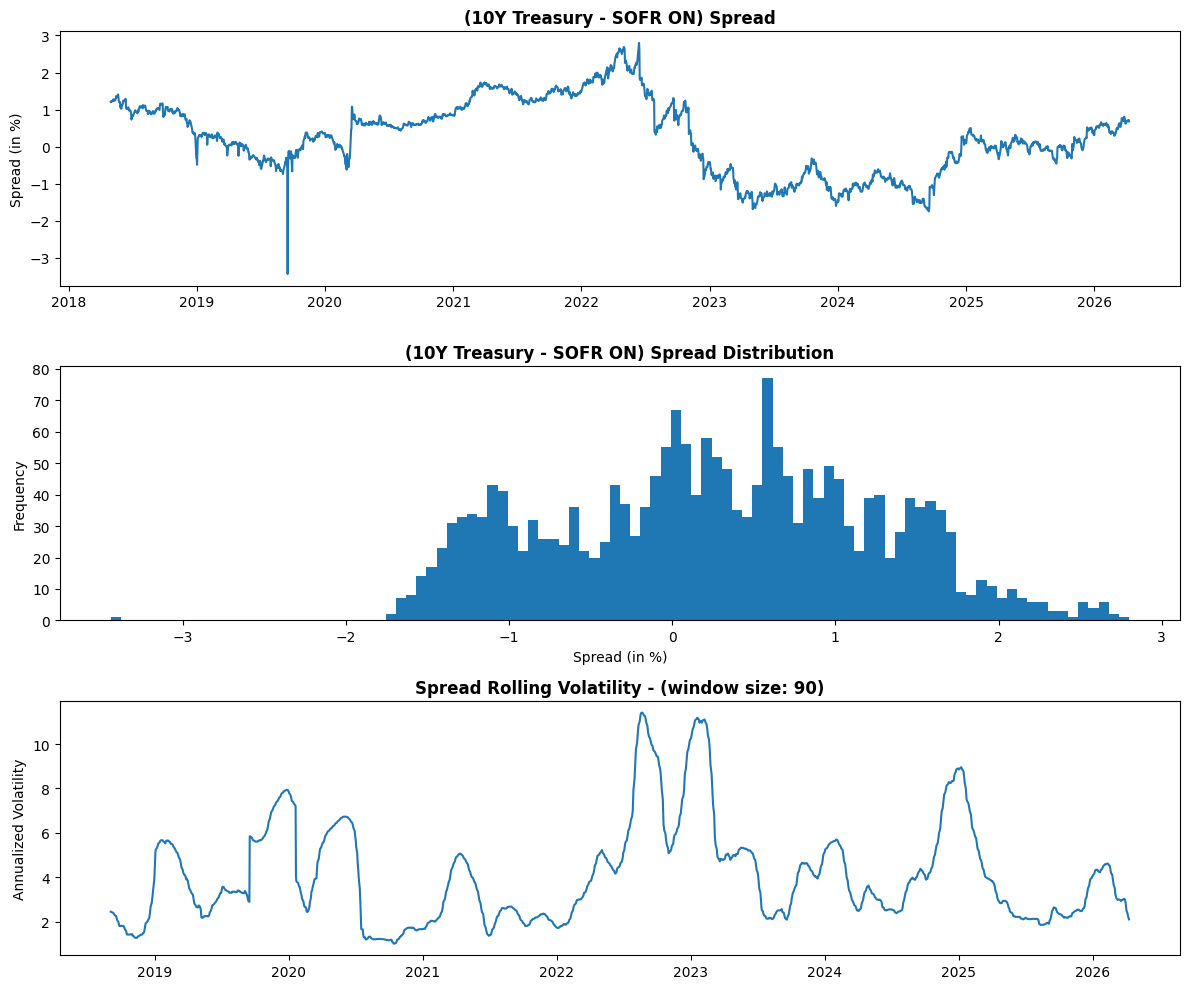

In [7]:
# plotting spread time-series
fig, axes = plt.subplots(3, 1, figsize = (12, 10))

axes[0].plot(spread)
axes[0].set_title("(10Y Treasury - SOFR ON) Spread", fontweight = 'bold')
axes[0].set_ylabel('Spread (in %)')

axes[1].hist(spread, bins = 100)
axes[1].set_title('(10Y Treasury - SOFR ON) Spread Distribution', fontweight = 'bold')
axes[1].set_ylabel('Frequency')
axes[1].set_xlabel('Spread (in %)')

axes[2].plot(rolling_vol)
axes[2].set_title(f"Spread Rolling Volatility - (window size: {window_size})", fontweight = 'bold')
axes[2].set_ylabel('Annualized Volatility')

plt.tight_layout()
plt.show()